# Вплив похибок вимірювальних каналів на точність прогнозування мікроклімату теплиці

Виконуваний звіт: увесь хід роботи з кодом, таблицями і рисунками.

---

## Постановка задачі

Спроектовано вимірювальний прилад на базі ESP32 з бюджетними датчиками:

| Канал | Датчик | Вимірювана величина |
|---|---|---|
| `T_air` | DHT22 | температура повітря |
| `RH_air` | DHT22 | відносна вологість |
| `CO2_air` | SGP30 | еквівалентна концентрація CO₂ |
| `LUX` | BH1750 | освітленість |
| `SOIL` | ємнісний + АЦП ESP32 | вологість субстрату |

**Питання дослідження:** наскільки похибки цих каналів спотворюють картину мікроклімату і як це позначиться на точності прогнозування?

## Метод

Прямі натурні вимірювання на цьому етапі недоступні, тому застосовано метод модельного експерименту:

1. **Опорний сигнал.** Взято дані реальної промислової теплиці, де клімат вимірювався повіреною апаратурою (Autonomous Greenhouse Challenge, Wageningen UR, ліцензія CC0). Ці показання прийнято за істинне значення вимірюваної величини.
2. **Модель вимірювального каналу.** Опорний сигнал пропускається через модель похибок кожного датчика, побудовану за паспортними характеристиками.
3. **Оцінка.** Порівняння опорного сигналу і модельного показання дає кількісну оцінку придатності каналу.

In [ ]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from gims import config as cfg
from gims.sensors import SENSOR_SPECS, corrupt_frame
from gims.datasets import load_compartment, clean_reference, describe

plt.rcParams["figure.figsize"] = (11, 3)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


def show_table(name):
    """Показати збережену таблицю результатів."""
    return pd.read_csv(cfg.TABLES / name)


def show_figure(name):
    """Показати збережений рисунок."""
    display(Image(filename=str(cfg.FIGURES / name)))

---
## 1. Опорні дані

Набір даних містить 6 відсіків теплиці, черрі-помідор, грудень 2019 — травень 2020, крок реєстрації 5 хвилин.

Опорний ряд проходить двоступеневу підготовку: відбраковування значень поза фізично допустимими межами і зняття одиничних збоїв апаратури фільтром Хампеля. Це необхідно, оскільки й промислова апаратура дає рідкісні збої, а опорний ряд має бути вільним від них — усі похибки в досліді вносяться керовано.

In [2]:
ref = clean_reference(load_compartment("Reference"), report=True)

print(f"\nОпорний ряд: {len(ref)} відліків, "
      f"{len(ref) * cfg.SAMPLE_PERIOD_S / 86400:.1f} діб")
print(f"Період: {ref.index.min()} — {ref.index.max()}")

describe(ref)

Відбраковано відліків поза фізичними межами:
  RH_air         1  (0.00 %)
  CO2_air        2  (0.00 %)
  I_glob        11  (0.02 %)
Знято одиничних викидів (фільтр Хампеля):
  T_air        226  (0.473 %)
  RH_air       134  (0.280 %)
  CO2_air      180  (0.376 %)
  LUX          150  (0.314 %)
  SOIL         320  (0.669 %)



Опорний ряд: 17617 відліків, 61.2 діб
Період: 2019-12-25 11:50:00 — 2020-02-24 15:50:00


,канал,величина,датчик,од. вим.,мін,середнє,макс,СКВ,"пропусків,%"
0,T_air,температура повітря,DHT22,°C,5.7,22.79,34.2,4.10,0.0
1,RH_air,відносна вологість повітря,DHT22,%RH,39.4,85.64,99.2,7.71,0.0
2,CO2_air,еквівалентна концентрація CO2,SGP30,ppm,283.0,609.21,1012.0,57.15,0.0
3,LUX,освітленість,BH1750,лк,0.0,9572.81,39042.0,6676.49,0.0
4,SOIL,вологість субстрату,CapSoilADC,%,73.4,84.39,94.9,3.95,0.0


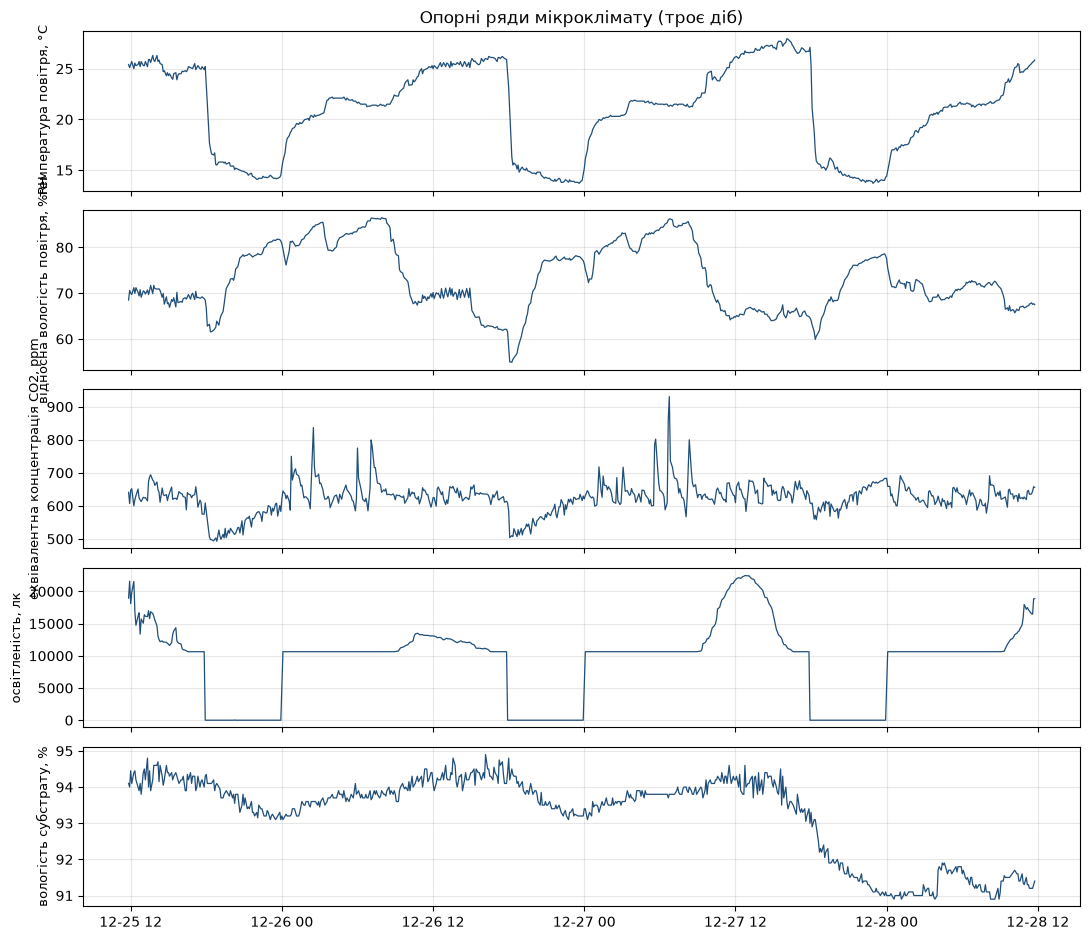

In [3]:
# Добова динаміка: видно цикл опалення, роботу досвічування,
# імпульси подачі CO2 і пилкоподібний характер поливу субстрату
week = ref.iloc[: 3 * 24 * 12]
chans = list(cfg.CHANNELS)

fig, axes = plt.subplots(len(chans), 1, figsize=(11, 1.9 * len(chans)), sharex=True)
for ax, ch in zip(axes, chans):
    meta = cfg.CHANNELS[ch]
    ax.plot(week.index, week[ch], lw=0.9, color="#1f4e79")
    ax.set_ylabel(f"{meta['descr']}, {meta['unit']}", fontsize=9)
axes[0].set_title("Опорні ряди мікроклімату (троє діб)")
plt.tight_layout()

---
## 2. Модель похибки вимірювального каналу

Канал моделюється як ланцюжок фізично осмислених перетворень:

```
істинне значення
  → методична похибка (датчик міряє не зовсім ту величину)
  → інерційність (аперіодична ланка 1-го порядку)
  → перехресна чутливість до інших величин
  → похибка коефіцієнта перетворення
  → систематичне зміщення (похибка калібрування)
  → дрейф у часі
  → випадковий шум
  → квантування
  → обмеження діапазоном
  → відмови каналу (пропуски, «залипання»)
= показання датчика
```

Параметри кожної складової взято з документації виробника або, де виробник величину не нормує, прийнято як експертну оцінку (поле `source`).

In [4]:
spec = SENSOR_SPECS["T_air"]
print(f"Канал: {spec.name}  |  датчик: {spec.sensor}\n")
print(f"  розкид систематичного зміщення : ±{spec.bias_sigma:.2f} {spec.unit}")
print(f"  СКВ випадкового шуму           : {spec.noise_sigma:.2f} {spec.unit}")
print(f"  роздільна здатність            : {spec.resolution} {spec.unit}")
print(f"  стала часу                     : {spec.tau_s:.0f} с")
print(f"  ймовірність втрати відліку     : {spec.dropout_prob * 100:.1f} %")
print(f"\n  джерело даних: {spec.source}")
print(f"  примітка: {spec.note}")

Канал: T_air  |  датчик: DHT22 (AM2302)

  розкид систематичного зміщення : ±0.29 °C
  СКВ випадкового шуму           : 0.10 °C
  роздільна здатність            : 0.1 °C
  стала часу                     : 20 с
  ймовірність втрати відліку     : 1.5 %

  джерело даних: mixed
  примітка: ±0.5°C, роздільна здатність 0.1°C — документація; інерційність і збої — оцінка


### Ключова особливість моделі: керовані складові

Два методи дозволяють ставити контрольовані досліди:

- `spec.scaled(k)` — масштабує всю похибку в *k* разів. При `k = 0` виходить ідеальний датчик, при `k = 1` — паспортна похибка, при `k > 1` — деградований канал. На цьому будується дослідження залежності точності прогнозу від рівня похибки.
- `spec.only("noise")` — лишає тільки одну складову, решту обнуляє. Дозволяє розкласти підсумкову похибку за джерелами і визначити, яке з них вносить вирішальний внесок.

In [5]:
# Перевірка коректності моделі: за нульового масштабу похибки
# показання має збігатися з істинним значенням
rng = np.random.default_rng(cfg.SEED)
ideal = corrupt_frame(ref, cfg.SAMPLE_PERIOD_S,
                      np.random.default_rng(cfg.SEED), scale=0.0)
real = corrupt_frame(ref, cfg.SAMPLE_PERIOD_S, rng, scale=1.0)

pd.DataFrame({
    "RMSE при scale=0 (ідеальний)": {
        c: np.sqrt(np.nanmean((ideal[c] - ref[c]) ** 2)) for c in chans},
    "RMSE при scale=1 (паспортний)": {
        c: np.sqrt(np.nanmean((real[c] - ref[c]) ** 2)) for c in chans},
}).round(2)

,RMSE при scale=0 (ідеальний),RMSE при scale=1 (паспортний)
T_air,0.02,0.13
RH_air,0.08,0.95
CO2_air,3.49,189.05
LUX,0.01,7996.29
SOIL,0.10,13.15


---
## 3. Зіставлення опорного сигналу і модельного показання

Синім — що відбувалося в теплиці насправді, червоним — що показав би наш прилад.

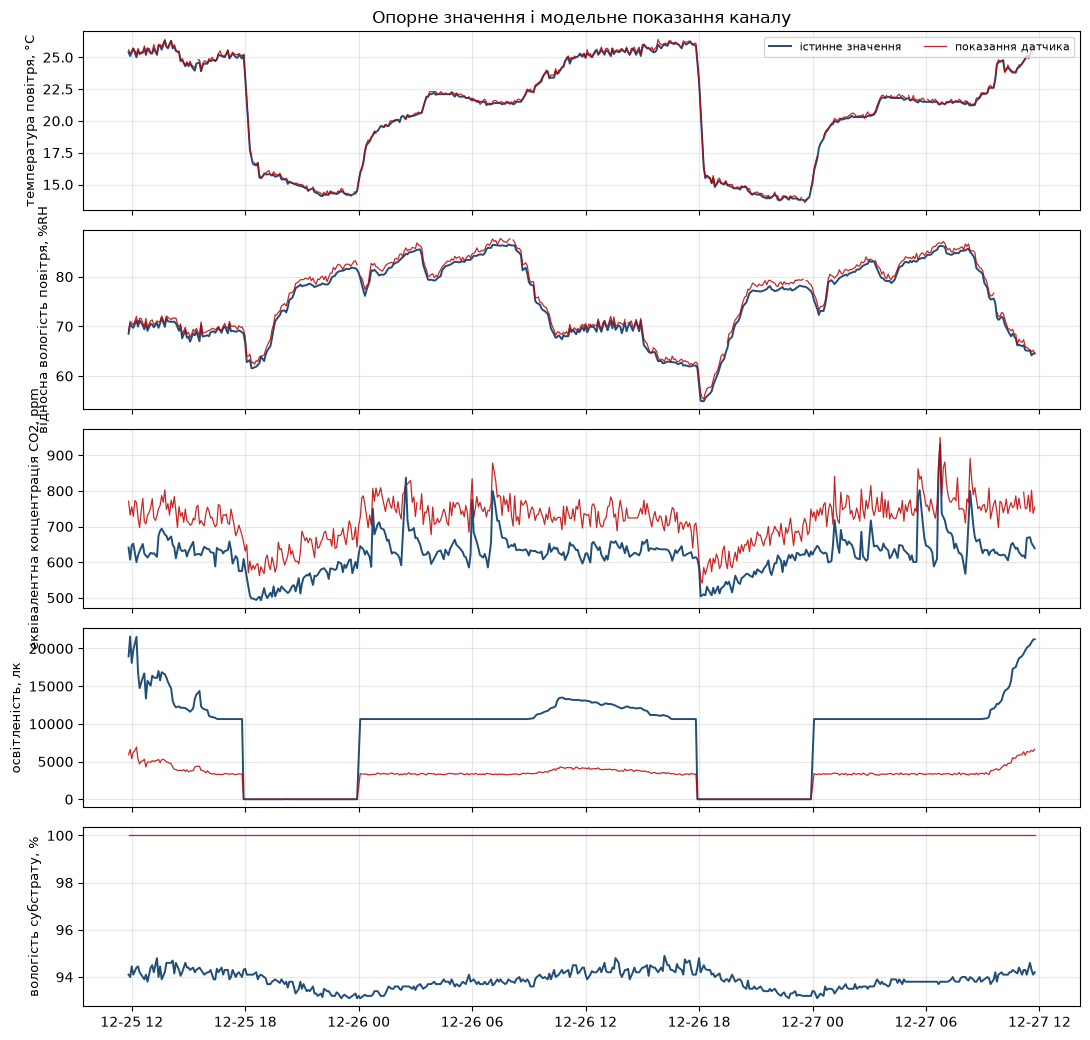

In [6]:
n_show = 2 * 24 * 12  # дві доби
fig, axes = plt.subplots(len(chans), 1, figsize=(11, 2.1 * len(chans)), sharex=True)
for ax, ch in zip(axes, chans):
    meta = cfg.CHANNELS[ch]
    ax.plot(ref.index[:n_show], ref[ch].iloc[:n_show], lw=1.4,
            color="#1f4e79", label="істинне значення")
    ax.plot(real.index[:n_show], real[ch].iloc[:n_show], lw=0.9,
            color="#c00000", alpha=0.85, label="показання датчика")
    ax.set_ylabel(f"{meta['descr']}, {meta['unit']}", fontsize=9)
axes[0].legend(fontsize=8, ncol=2, loc="upper right")
axes[0].set_title("Опорне значення і модельне показання каналу")
plt.tight_layout()

---
## 4. Придатність вимірювальних каналів

Уведемо відношення сигнал/похибка:

$$\text{SNR} = \frac{\sigma_{\text{сигналу}}}{\sigma_{\text{похибки}}}$$

Прогнозуванню підлягають **зміни** величини. Якщо похибка каналу перевищує розмах цих змін (SNR < 1), датчик реєструє переважно власну похибку, а не стан об'єкта. Нарощування обсягу навчальних даних такий канал не рятує.

Додатково оцінимо SNR **після ідеального лінійного калібрування** каналу за еталоном. Систематичні складові (зміщення нуля, похибка коефіцієнта перетворення) при цьому усуваються, лишається невитравна частина. Для лінійного калібрування СКВ залишку дорівнює $\sigma_{\text{сигналу}}\sqrt{1-r^2}$, звідки $\text{SNR}_{\text{кал}} = 1/\sqrt{1-r^2}$.

**Різниця між двома оцінками і є інженерним висновком:** чи достатньо відкалібрувати датчик, чи потрібна його заміна.

In [7]:
from scripts.demo import channel_metrics

channel_metrics(ref, real)

,канал,датчик,од. вим.,СКВ сигналу,СКВ похибки,RMSE,зміщення,сигнал/похибка,після калібрування,кореляція,"пропусків,%",висновок
0,T_air,DHT22,°C,4.11,0.11,0.13,0.07,38.96,38.98,1.000,1.51,придатний
1,RH_air,DHT22,%RH,7.72,0.49,0.95,0.82,15.68,15.71,0.998,1.46,придатний
2,CO2_air,SGP30,ppm,57.12,63.18,189.05,178.18,0.90,1.23,0.582,0.47,НЕПРИДАТНИЙ
3,LUX,BH1750,лк,6672.01,4576.85,7996.29,-6556.91,1.46,20.03,0.999,0.23,придатний
4,SOIL,CapSoilADC,%,3.95,1.92,13.15,13.01,2.06,2.08,0.876,0.06,придатний із застереженнями


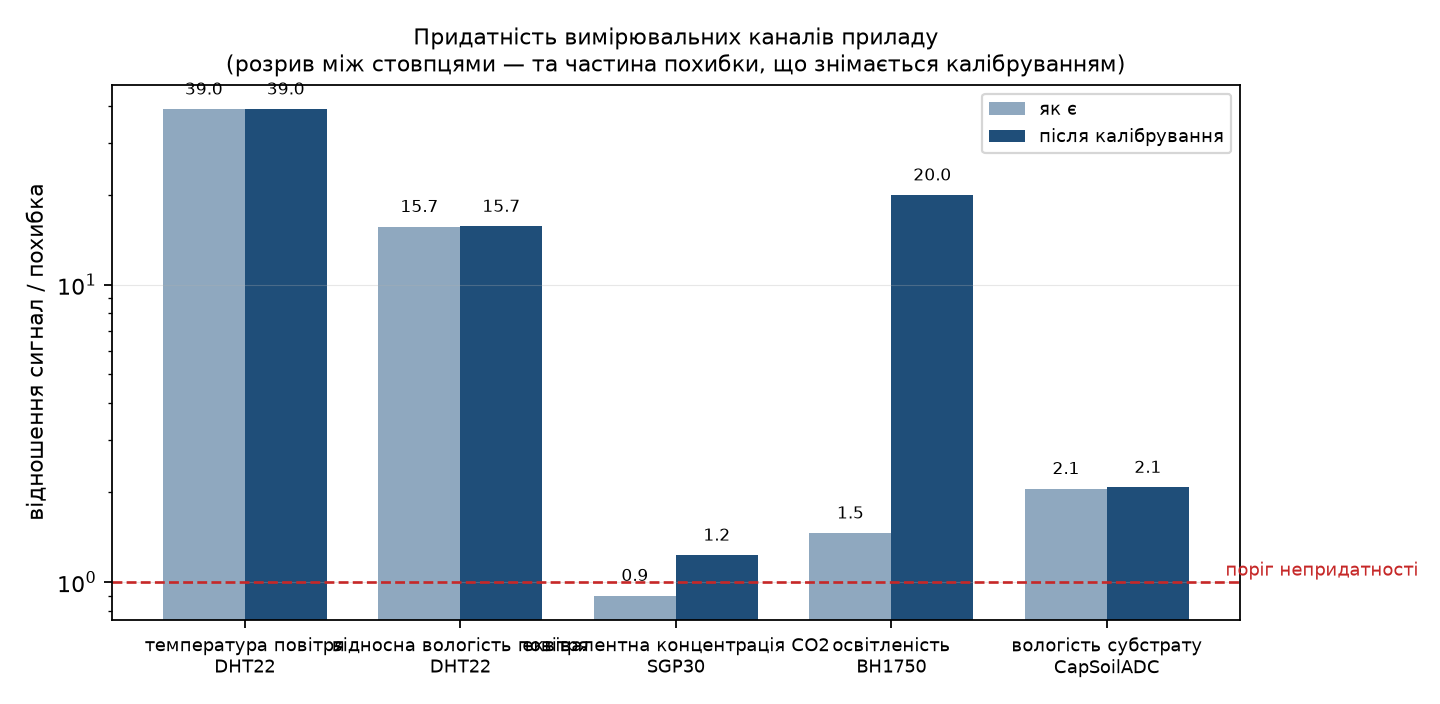

In [8]:
show_figure("fig03_channel_snr.png")

Канали температури і вологості придатні без додаткових заходів. Канал освітленості придатний після калібрування: розрив між стовпцями показує, що похибка там переважно систематична. Канал CO₂ лишається за порогом придатності і після калібрування.

---
# 5. Результати дослідів

## 5.1. Дослід E1: базова точність прогнозування

Перш ніж вивчати вплив похибок, треба встановити точку відліку: яка точність узагалі досяжна на ідеальних даних і яка модель її забезпечує.

Обов'язковою точкою відліку є наївний прогноз «величина не зміниться». На горизонті 15 хвилин інерція теплиці велика, і перевершити його не так просто.

In [9]:
e1 = show_table("table02_baseline_accuracy.csv")
best = (e1[e1["модель"] != "Наївний"]
        .sort_values("RMSE")
        .groupby(["канал", "горизонт,хв"], as_index=False)
        .first()
        .sort_values(["канал", "горизонт,хв"]))
best[["канал", "горизонт,хв", "модель", "RMSE",
      "виграш над наївним,%", "DM-статистика", "p-значення"]]

,канал,"горизонт,хв",модель,RMSE,"виграш над наївним,%",DM-статистика,p-значення
0,CO2_air,15,ВипадковийЛіс,28.5892,28.8,-12.05,0.000000e+00
1,CO2_air,30,ВипадковийЛіс,31.6998,26.4,-8.63,0.000000e+00
2,CO2_air,60,ВипадковийЛіс,33.4105,34.2,-7.03,2.650000e-12
3,RH_air,15,ВипадковийЛіс,1.0979,18.1,-2.47,1.370000e-02
4,RH_air,30,ВипадковийЛіс,1.4142,32.2,-3.87,1.120000e-04
5,RH_air,60,ВипадковийЛіс,1.7179,45.2,-4.34,1.470000e-05
6,T_air,15,ВипадковийЛіс,0.4446,32.7,-3.47,5.250000e-04
7,T_air,30,ВипадковийЛіс,0.5834,49.6,-3.76,1.740000e-04
8,T_air,60,ВипадковийЛіс,0.7359,62.2,-4.10,4.200000e-05


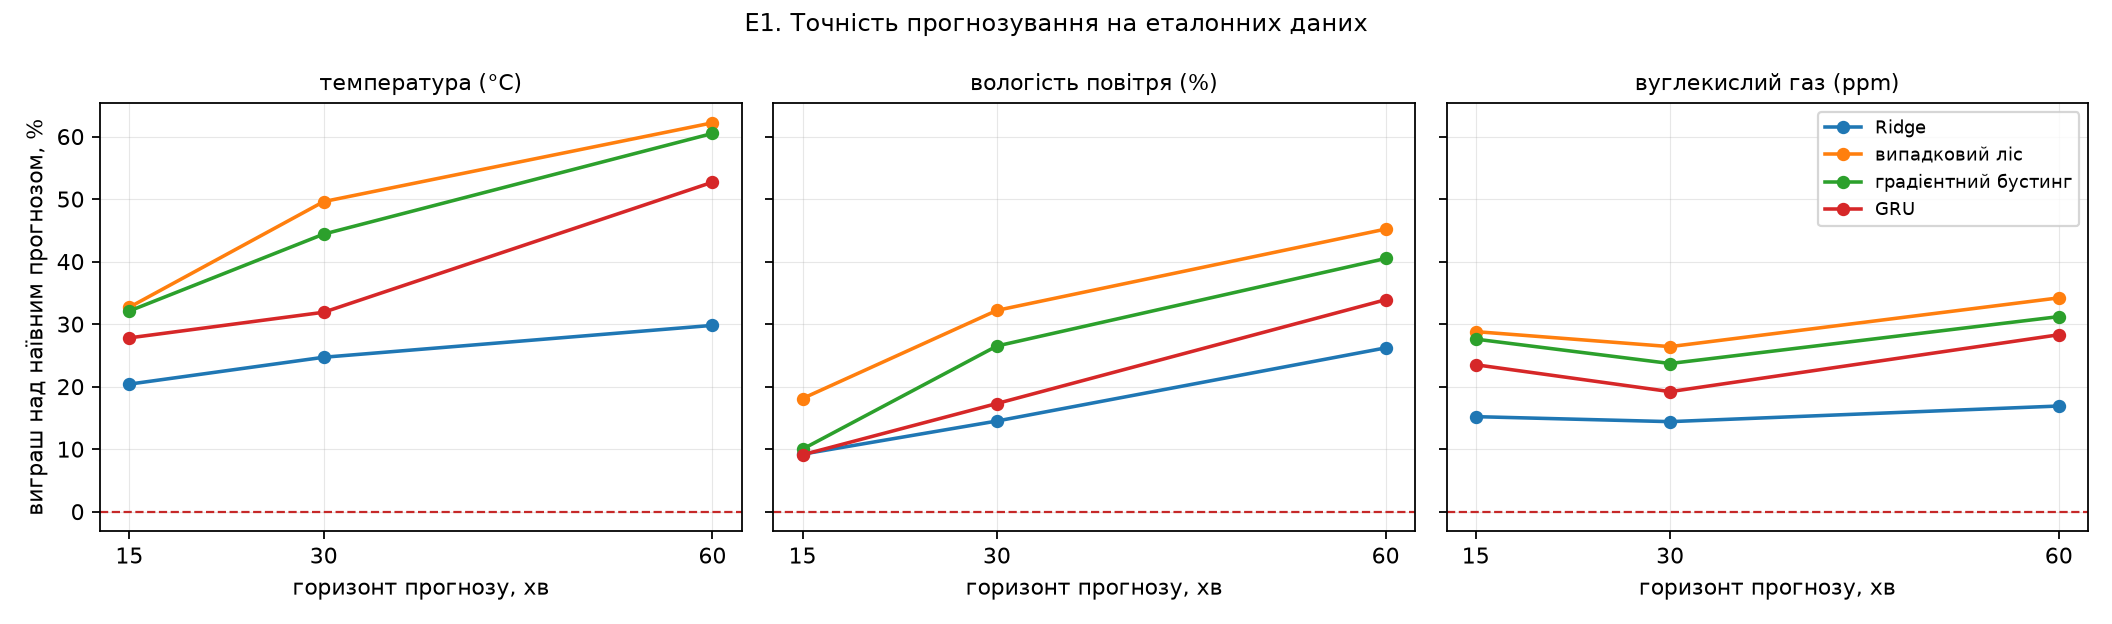

In [10]:
show_figure("fig04_baseline_accuracy.png")

**Спостереження 1. Виграш зростає з горизонтом прогнозу.** На 15 хвилинах інерція теплиці настільки велика, що наївний прогноз уже непоганий, і моделі додають 18–33 %. На годинному горизонті наївний прогноз розсипається, і виграш сягає 62 %. Тобто модель потрібна саме там, де працює керування — на випередженні.

**Спостереження 2. Ансамблі дерев переважають рекурентну нейромережу** на всіх каналах і горизонтах. Це типово для табличних задач такого обсягу (12 тисяч навчальних відліків), і про це варто сказати прямо: ускладнення моделі тут не окуповується.

Значущість переваги над наївним прогнозом підтверджена тестом Діболда — Маріано.

---
## 5.2. Дослід E2: деградація від рівня похибки каналів

Похибка всіх каналів масштабується спільним коефіцієнтом: 0 — ідеальні вимірювання, 1 — паспортна похибка обраних датчиків, 5 — канали в передаварійному стані.

In [11]:
e2 = show_table("table04_noise_level.csv")
e2.pivot(index="рівень похибки", columns="канал", values="зростання RMSE, разів")

канал,CO2_air,RH_air,T_air
рівень похибки,,,
0.0,1.00,1.00,1.00
0.5,2.63,1.12,1.05
1.0,5.09,1.45,1.13
2.0,10.31,2.33,1.32
3.0,15.63,3.05,1.57
5.0,27.11,4.94,2.05


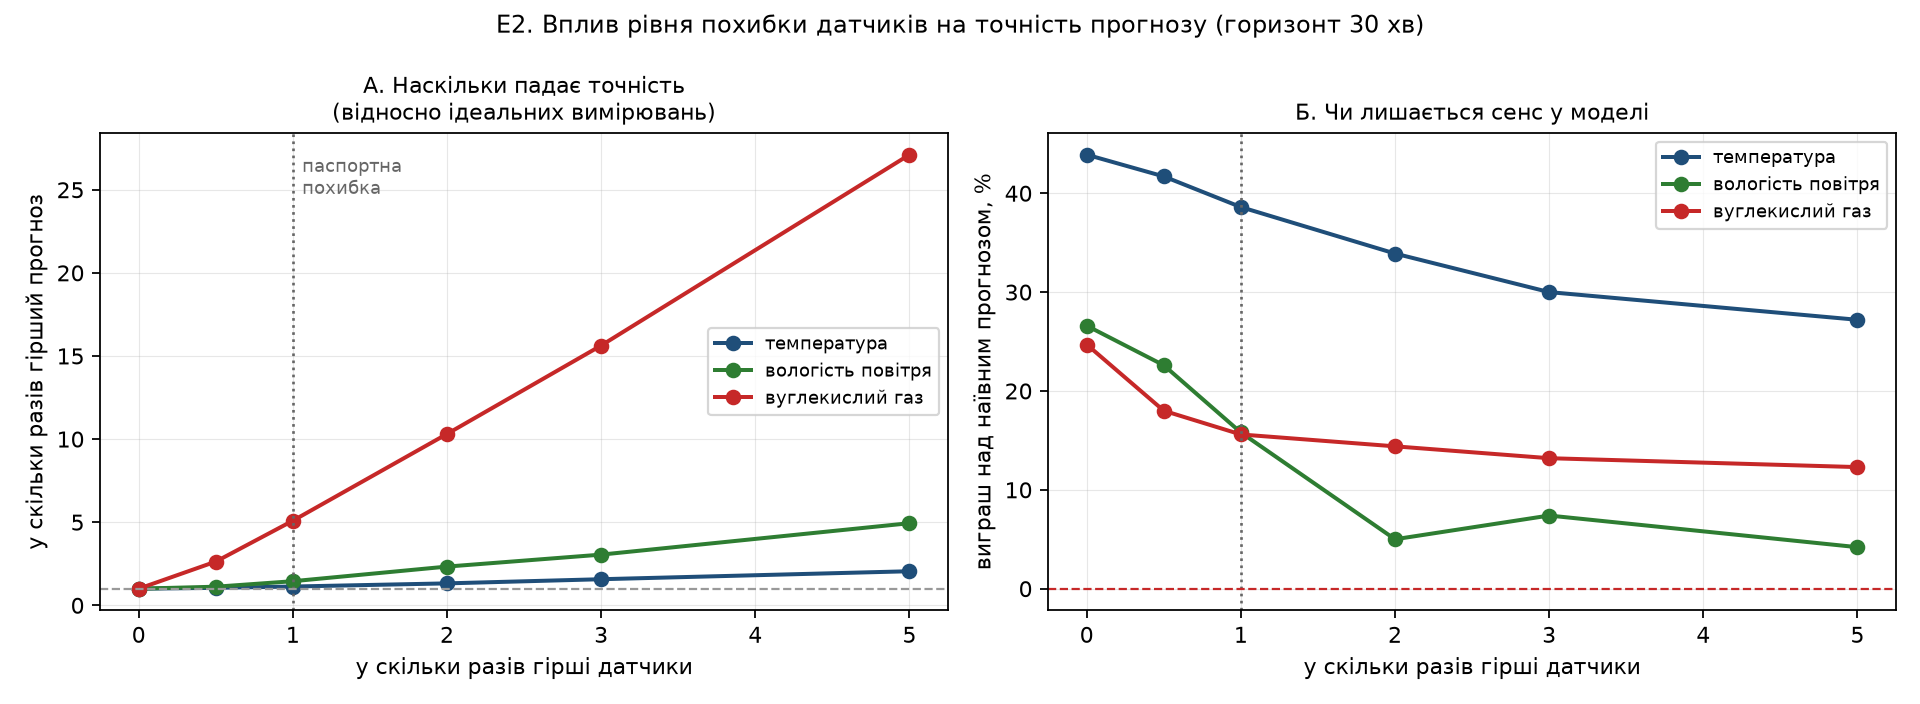

In [12]:
show_figure("fig06_noise_level.png")

**Головний результат досліду: деградація вкрай нерівномірна по каналах.** За паспортної похибки датчиків похибка прогнозування зростає в 1,13 раза для температури, у 1,45 раза для вологості і в 5,09 раза для концентрації CO₂. За п'ятикратного погіршення каналів розрив стає ще різкішим: 2,05, 4,94 і 27,1 раза відповідно.

Це означає, що формулювання «бюджетні датчики погіршують прогноз» неточне. Погіршує його один конкретний канал, а два інші лишаються придатними навіть за помітної деградації апаратури.

**Права панель відповідає на питання, чи лишається сенс у моделі.** Для температури виграш над наївним прогнозом знижується плавно: з 43,9 % за ідеальних вимірювань до 38,6 % за паспортної похибки і 25,8 % за п'ятикратної. Для вологості падіння різкіше — з 26,6 % до 15,8 %, а за подвійної похибки виграш обвалюється до 5 %, тобто модель майже перестає перевершувати просте припущення «величина не зміниться».

---
## 5.3. Дослід E3: внесок окремих складових похибки

Попередній дослід показав, скільки точності втрачається. Цей відповідає на інженерне питання: що саме в датчику погано і куди докладати зусиль. Кожна складова вмикається окремо при вимкнених решті.

Складові поділено за тим, чим вони усуваються: шум — фільтрацією, зміщення — калібруванням, дрейф — періодичною повіркою, а квантування, інерційність і методична похибка — лише заміною датчика.

In [13]:
e3 = show_table("table05_error_components.csv")
e3[~e3["код"].isin(["all", "none"])][
    ["канал", "складова", "приріст RMSE", "частка внеску,%",
     "достовірність", "чим лікується"]]

,канал,складова,приріст RMSE,"частка внеску,%",достовірність,чим лікується
0,T_air,випадковий шум,0.007,13.5,у межах розкиду,фільтрація
1,T_air,систематичне зміщення,0.038,75.3,у межах розкиду,калібрування
2,T_air,дрейф у часі,0.048,95.9,значущий,періодична повірка
3,T_air,квантування,0.015,27.2,значущий,заміна датчика
4,T_air,інерційність,0.012,23.3,значущий,заміна датчика
5,T_air,перехресна чутливість,-0.010,-19.1,значущий,програмна компенсація
6,T_air,відмови каналу,0.010,19.4,значущий,відновлення даних
7,T_air,методична похибка,0.007,13.5,значущий,ЛИШЕ заміна датчика
10,RH_air,випадковий шум,0.018,3.6,значущий,фільтрація
11,RH_air,систематичне зміщення,0.214,46.0,значущий,калібрування


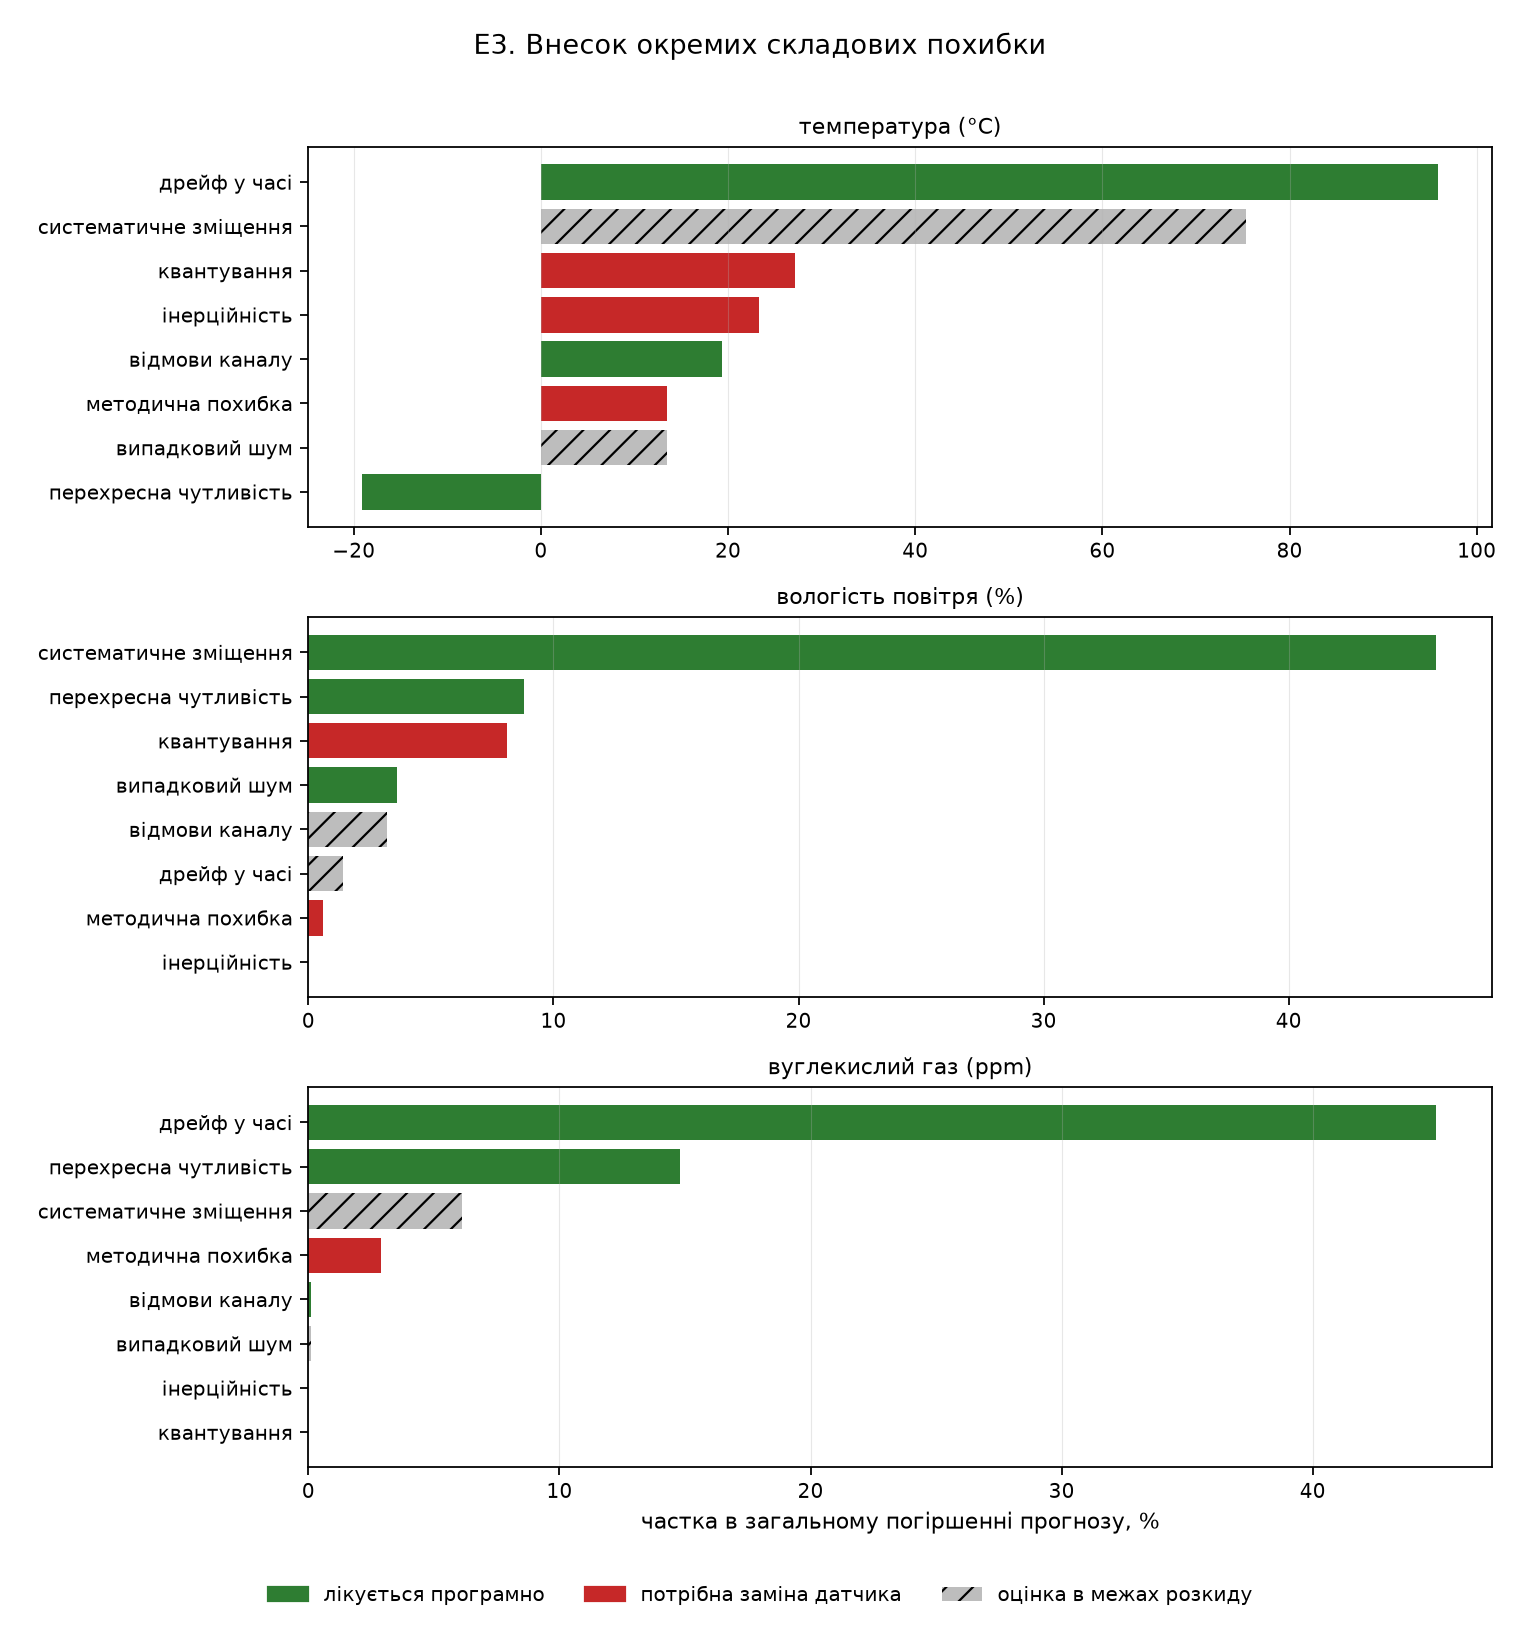

In [14]:
show_figure("fig07_error_components.png")

**Про методику розрахунку часток.** Частки внеску обчислюються за квадратами похибок, оскільки за незалежних джерел складаються дисперсії, а не середньоквадратичні відхилення. Навіть так сума часток не зобов'язана дорівнювати 100 %: джерела похибки не повністю незалежні, а модель прогнозування реагує на них нелінійно. Внески, що не перевищують подвоєної стандартної похибки середнього за шістьма незалежними прогонами, позначені як недостовірні і на рисунку заштриховані.

**Температура.** Повна деградація мала: RMSE зростає з 0,639 до 0,736 °C. Формально переважає дрейф (95,9 %), однак в абсолютному вираженні йдеться про соті частки градуса, і практичного значення це не має. Внесок систематичного зміщення оцінити не вдалося: у кожного примірника датчика воно своє, тому розкид між прогонами перекриває сам ефект.

**Вологість.** Виразно переважає систематичне зміщення — 46,0 % за повної деградації з 1,53 до 2,23 %RH. Це сприятливий випадок: зміщення усувається калібруванням за еталонним гігрометром, заміна датчика не потрібна.

**Концентрація CO₂.** Основний внесок дають дрейф нульової лінії (44,9 %) і перехресна чутливість до вологості (14,8 %). Обидві складові характерні саме для металооксидних датчиків.

**Важливе застереження, без якого висновок вийшов би хибним.** Формально дрейф лікується періодичною повіркою, а перехресна чутливість — програмною компенсацією, і можна було б виснувати, що SGP30 достатньо частіше калібрувати. На практиці це нездійсненно: штатний алгоритм самокалібрування MOX-датчика приймає за нульовий рівень мінімальну концентрацію, що спостерігалася за останню добу, у припущенні, що приміщення періодично провітрюється до рівня зовнішнього повітря близько 400 ppm. У теплиці з дозуванням CO₂ такого стану не виникає ніколи, опорної точки для калібрування немає. Тому висновок розділу 5.4 лишається чинним: канал потребує заміни датчика, а не зміни регламенту обслуговування.

---
## 5.4. Дослід E2-CO2: обґрунтування вибору датчика CO₂

Аналіз показав непридатність каналу на SGP30. Але цей висновок спирався на гіпотезу про поведінку металооксидного датчика в теплиці, а не на паспортні дані. Гіпотезу треба перевірити.

### Частина А. Чутливість висновку до припущення

Коефіцієнт `measurand_gain` змінюється від украй песимістичного 0,1 до оптимістичного 1,0 (датчик ідеально стежить за концентрацією CO₂).

In [15]:
show_table("table03a_co2_sensitivity.csv")

,measurand_gain,сигнал/похибка,"RMSE прогнозу, ppm",СКВ за прогонами,"виграш над наївним,%"
0,0.10,0.78,174.5,40.7,12.7
1,0.25,0.83,171.0,39.5,13.6
2,0.50,0.90,165.0,38.2,15.6
3,0.75,0.94,160.5,39.4,17.7
4,0.90,0.94,158.2,41.2,19.1
5,1.00,0.92,157.6,41.0,19.5


### Частина Б. Порівняння з датчиками недисперсійного інфрачервоного принципу дії

На відміну від металооксидних, датчики NDIR вимірюють поглинання інфрачервоного випромінювання молекулами CO₂ — тобто саму цільову величину.

In [16]:
show_table("table03b_co2_sensor_choice.csv")

,датчик,принцип,сигнал/похибка,після калібрування,"RMSE прогнозу, ppm",СКВ за прогонами,"виграш над наївним,%"
0,ідеальний канал (межа),—,inf,inf,32.9,0.0,23.7
1,"SGP30 (MOX, eCO2)",MOX,0.90,1.19,165.0,38.2,15.6
2,MH-Z19B (NDIR),NDIR,2.46,2.57,43.4,8.1,28.1
3,SCD30 (NDIR),NDIR,4.28,4.34,35.4,3.2,26.3


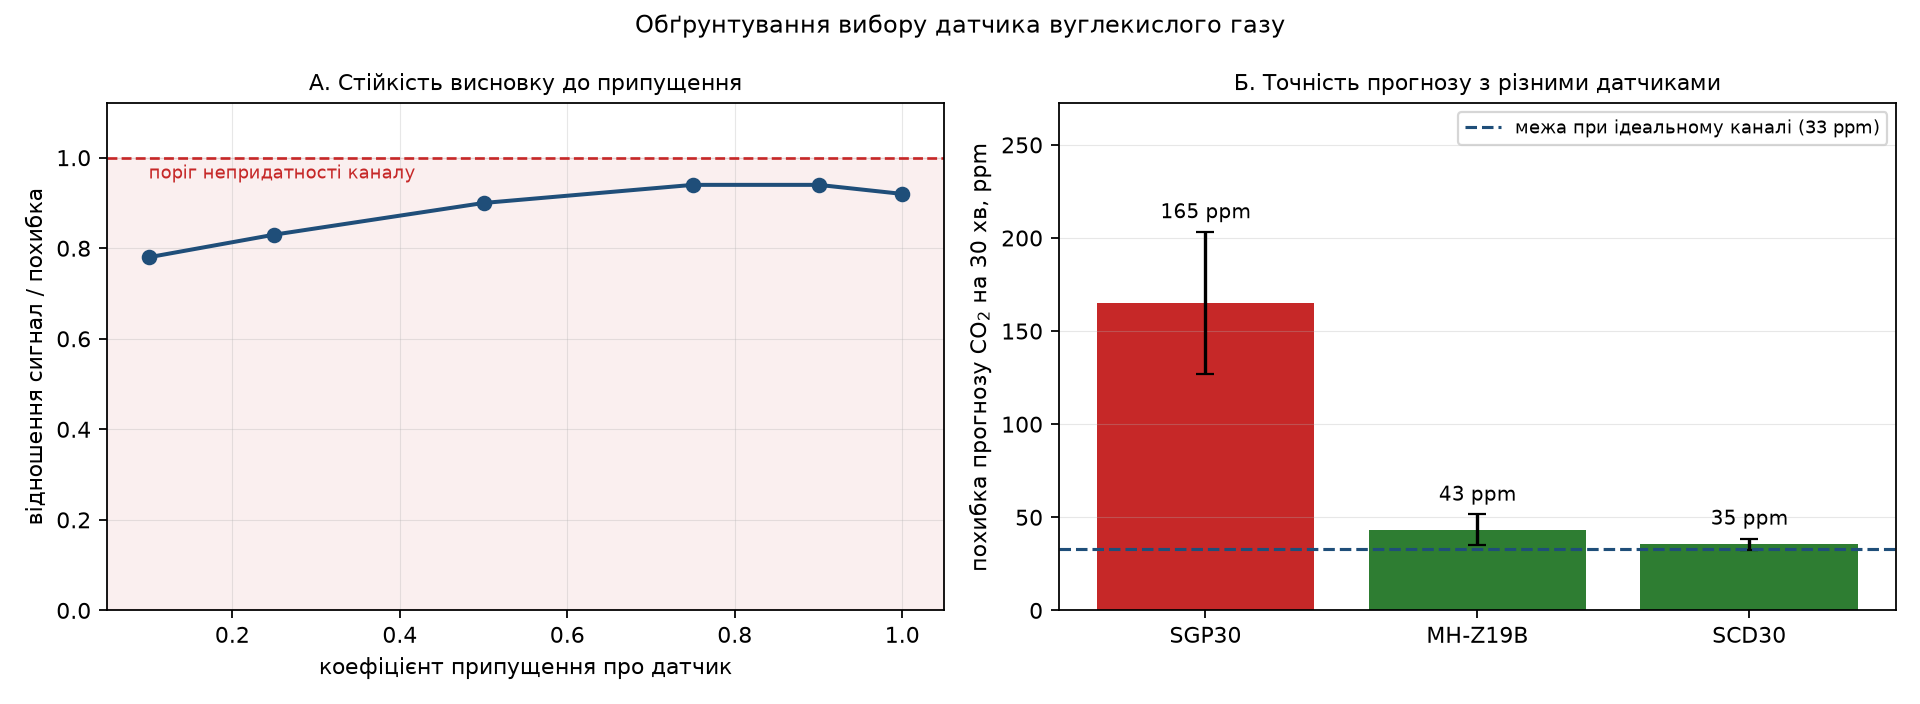

In [17]:
show_figure("fig05_co2_sensor_choice.png")

**Висновок за дослідом.** Навіть за найсприятливішого припущення відношення сигнал/похибка каналу на SGP30 не перевищує 0,94, тобто лишається нижче порога придатності. Висновок про непридатність не залежить від прийнятої гіпотези: канал обмежує не вона, а нормована похибка 15 % від виміряного значення за середньоквадратичного відхилення корисного сигналу всього 57 ppm.

Заміна SGP30 на SCD30 знижує похибку прогнозування концентрації CO₂ в 4,7 раза і виводить канал практично на теоретичну межу (35,4 ppm проти 32,9 ppm за ідеальних вимірювань). Датчик MH-Z19B дешевший і також прийнятний (43,4 ppm).

---
## 5.5. Дослід E4: сенсорна фузія — чи окупається кожен датчик

З набору ознак почергово виключається один канал приладу, і вимірюється приріст похибки прогнозування. Чим він більший, тим потрібніший датчик. Така оцінка чесніша за послідовне нарощування набору, оскільки враховує взаємне дублювання каналів.

In [18]:
e4 = show_table("table06b_fusion_dropout.csv")
e4.pivot(index="виключений датчик", columns="канал",
         values="втрата точності,%").loc[list(cfg.CHANNELS)]

канал,CO2_air,RH_air,T_air
виключений датчик,,,
T_air,0.6,0.6,60.9
RH_air,1.1,8.9,3.4
CO2_air,-15.6,1.4,-1.3
LUX,0.7,-2.0,14.4
SOIL,0.8,-2.6,-0.0


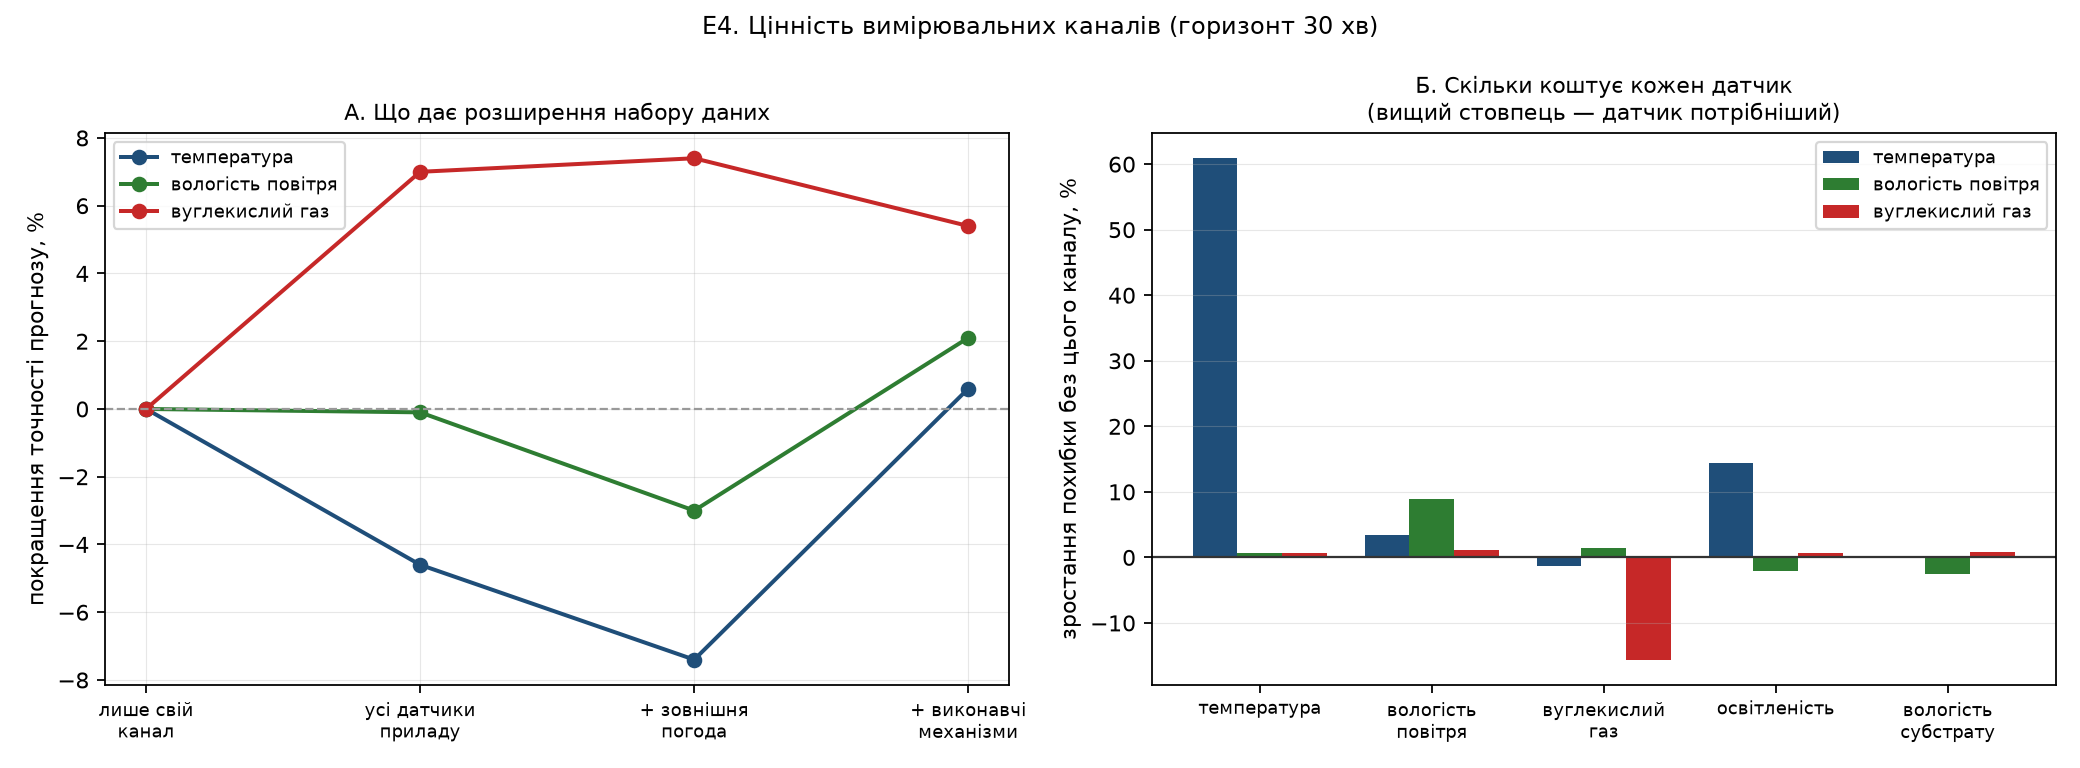

In [19]:
show_figure("fig08_fusion.png")

**Канал CO₂ погіршує власний прогноз.** Виключення каналу CO₂ з набору ознак не погіршує, а покращує прогнозування концентрації CO₂ на 15,6 % — середньоквадратична похибка знижується зі 167,7 до 141,6 ppm. Модель точніше відновлює концентрацію за температурою, вологістю, освітленістю і станом системи дозування, ніж за показаннями власного датчика.

Механізм такий. Дрейф нульової лінії металооксидного датчика має характер випадкового блукання. Модель використовує показання каналу як предиктор, однак передбачити випадкове блукання принципово неможливо, і внесена ним похибка виявляється більшою за ту інформацію, яку канал несе. Отже, канал на SGP30 не просто недостатньо точний — він гірший за своє відсутнє.

**Канал вологості субстрату не бере участі в прогнозуванні повітряних параметрів.** Зміна похибки при його виключенні лежить у діапазоні від −2,6 % до +0,8 %, тобто в межах розкиду між прогонами. Це не означає марності датчика взагалі: для керування поливом він необхідний, але в задачі прогнозування мікроклімату внеску не дає.

**Канал освітленості суттєвий для прогнозу температури** (+14,4 % похибки при виключенні), що фізично зрозуміло: сонячна радіація є основним джерелом нагріву теплиці у світлий час доби.

**Спостереження про джерело корисної інформації.** При послідовному нарощуванні набору ознак прогноз температури спочатку погіршується на 7,4 % і виходить у плюс лише після додавання станів виконавчих механізмів — опалювальних контурів, кватирок, завіс і досвічування. Іншими словами, для моделі цінні не стільки вимірювання сусідніх величин, скільки відомості про причини зміни клімату. Для інформаційно-вимірювальної системи теплиці це означає, що доступ до сигналів керування важливіший за збільшення кількості датчиків.

---
## 5.6. Дослід E5: чи можна повернути точність програмно

Перевіряються способи обробки даних, доступні розробникові приладу без заміни апаратури: фільтрація, калібрування за образцовим приладом і навчання моделі на кількох реалізаціях похибки.

Показник «відіграно втрат» відповідає на питання прямо: 0 % відповідає необробленим показанням датчика, 100 % — рівню ідеальних вимірювань.

Поправка при калібруванні визначається **лише за навчальною частиною вибірки** — так само, як її знайшли б при пусконалагодженні, звіривши прилад з образцовим протягом обмеженого часу. Використання для цього контрольної частини було б витоком інформації з майбутнього і завищило б результат.

In [20]:
e5 = show_table("table07_compensation.csv")
e5.pivot(index="спосіб обробки", columns="канал", values="відіграно втрат,%")

канал,CO2_air,RH_air,T_air
спосіб обробки,,,
без обробки,0.0,0.0,0.0
експоненційне згладжування,-2.5,7.3,45.4
калібрування + медіанний фільтр,78.2,87.0,-10.8
калібрування за еталоном,78.4,100.9,76.2
медіанний фільтр,0.3,-9.0,-70.0
навчання з аугментацією,-11.9,3.0,86.3
ідеальні вимірювання (межа),100.0,100.0,100.0


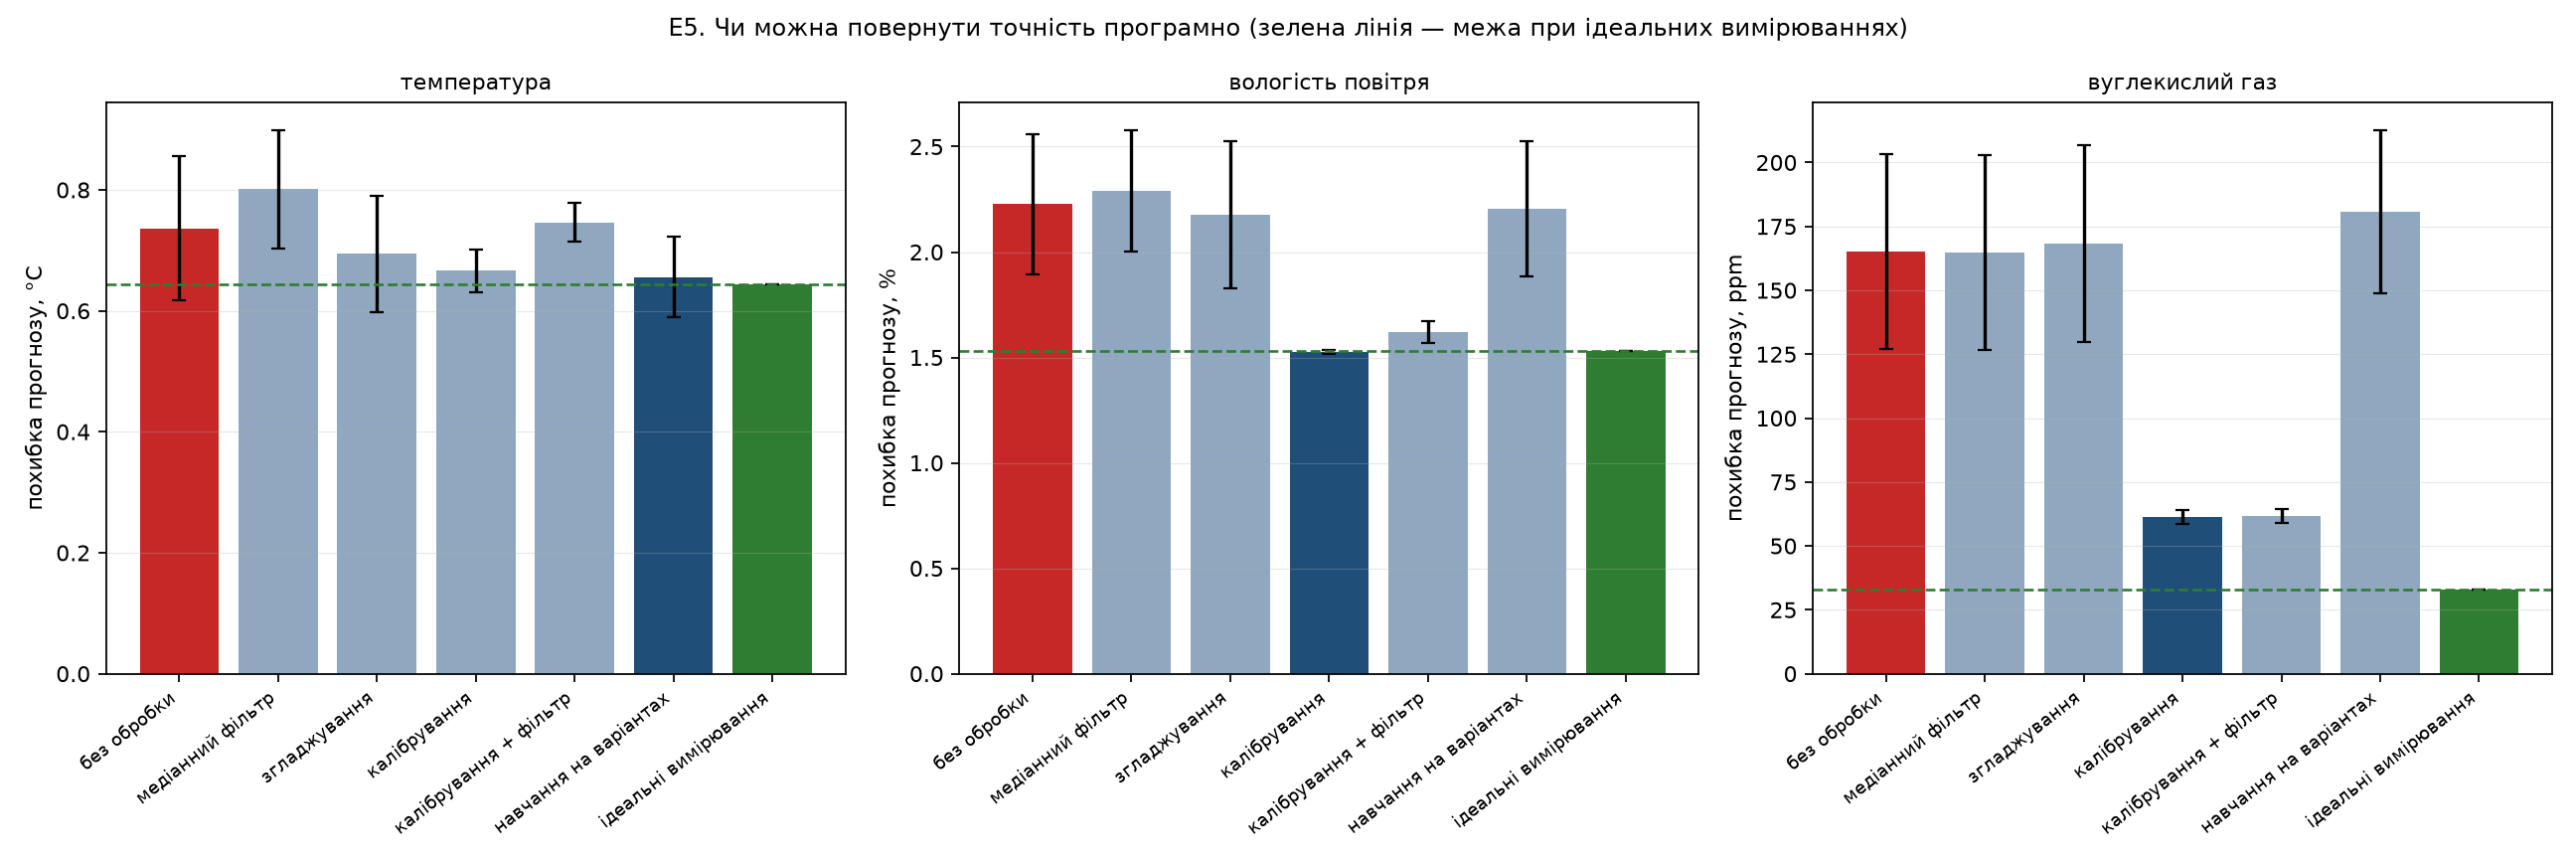

In [21]:
show_figure("fig09_compensation.png")

**Фільтрація не відновлює точність і в низці випадків погіршує її.** Медіанний фільтр збільшує похибку прогнозування температури на 70 % від величини втрат. Причина в тому, що похибки бюджетних датчиків мають переважно систематичний характер — зміщення, дрейф, спектральна невідповідність, — тоді як фільтрація призначена для придушення випадкової складової, частка якої невелика. При цьому фільтр вносить додаткове запізнення, що для задачі випереджального прогнозування критично.

**Калібрування за образцовим приладом є основним засобом відновлення точності.** Для каналу вологості воно повертає точність практично повністю, для температури — на 76 %, для концентрації CO₂ — на 78 %.

**Навчання на кількох реалізаціях похибки ефективне лише там, де похибка випадкова.** Для температури цей спосіб виявився найкращим (86 %), для вологості і CO₂ — практично марним: усереднення за реалізаціями не усуває систематичного зміщення і не робить передбачуваним випадкове блукання нульової лінії.

**Ключовий висновок для каналу CO₂.** Калібрування знижує похибку прогнозування зі 165 до 61 ppm, однак датчик SCD30 без жодного калібрування забезпечує 35 ppm. Відкалібрований SGP30 лишається майже вдвічі гіршим за некалібрований датчик NDIR. Програмна компенсація не є альтернативою вибору адекватного первинного перетворювача.

---
## 5.7. Дослід E6: виявлення відмов вимірювального каналу

Прогноз мікроклімату втрачає сенс, якщо система не помічає, що датчик несправний. Перевіряється, чи можна виявляти відмови тією самою моделлю, яка вже побудована для прогнозування, без установлення додаткової апаратури.

**Принцип — аналітична надмірність.** Величина оцінюється за іншими каналами приладу, зовнішньою погодою і станами виконавчих механізмів, але не за власною історією. Розбіжність між показанням датчика і такою оцінкою слугує ознакою відмови.

Передбачати канал за його ж минулими значеннями не можна: при відмові спотворюється і вхід алгоритму, і його вихід. Залиплий датчик безпомилково передбачає сам себе, нев'язка лишається нульовою, і відмова проходить непоміченою.

**Два правила спрацювання.** Поріг за нев'язкою реагує на різкі відмови. Накопичувальна сума (CUSUM) складає малі односпрямовані відхилення і тому виявляє повільне сповзання показань, невідрізниме від норми за миттєвим значенням.

**Пороги підбираються за допустимою частотою хибних тривог** — одне спрацювання на добу на справному каналі. Це принципово для коректності порівняння: чутливість будь-якого алгоритму можна довести до ста відсотків, якщо дозволити йому тривожитися постійно.

In [22]:
e6 = show_table("table08_fault_detection.csv")
e6.pivot(index="вид відмови", columns="канал", values="частка виявлення,%")

канал,CO2_air,RH_air,T_air
вид відмови,,,
залипання значення,16.7,16.7,38.9
обрив каналу,16.7,16.7,38.9
одиничні викиди,100.0,100.0,5.6
сповзання показань,100.0,100.0,100.0


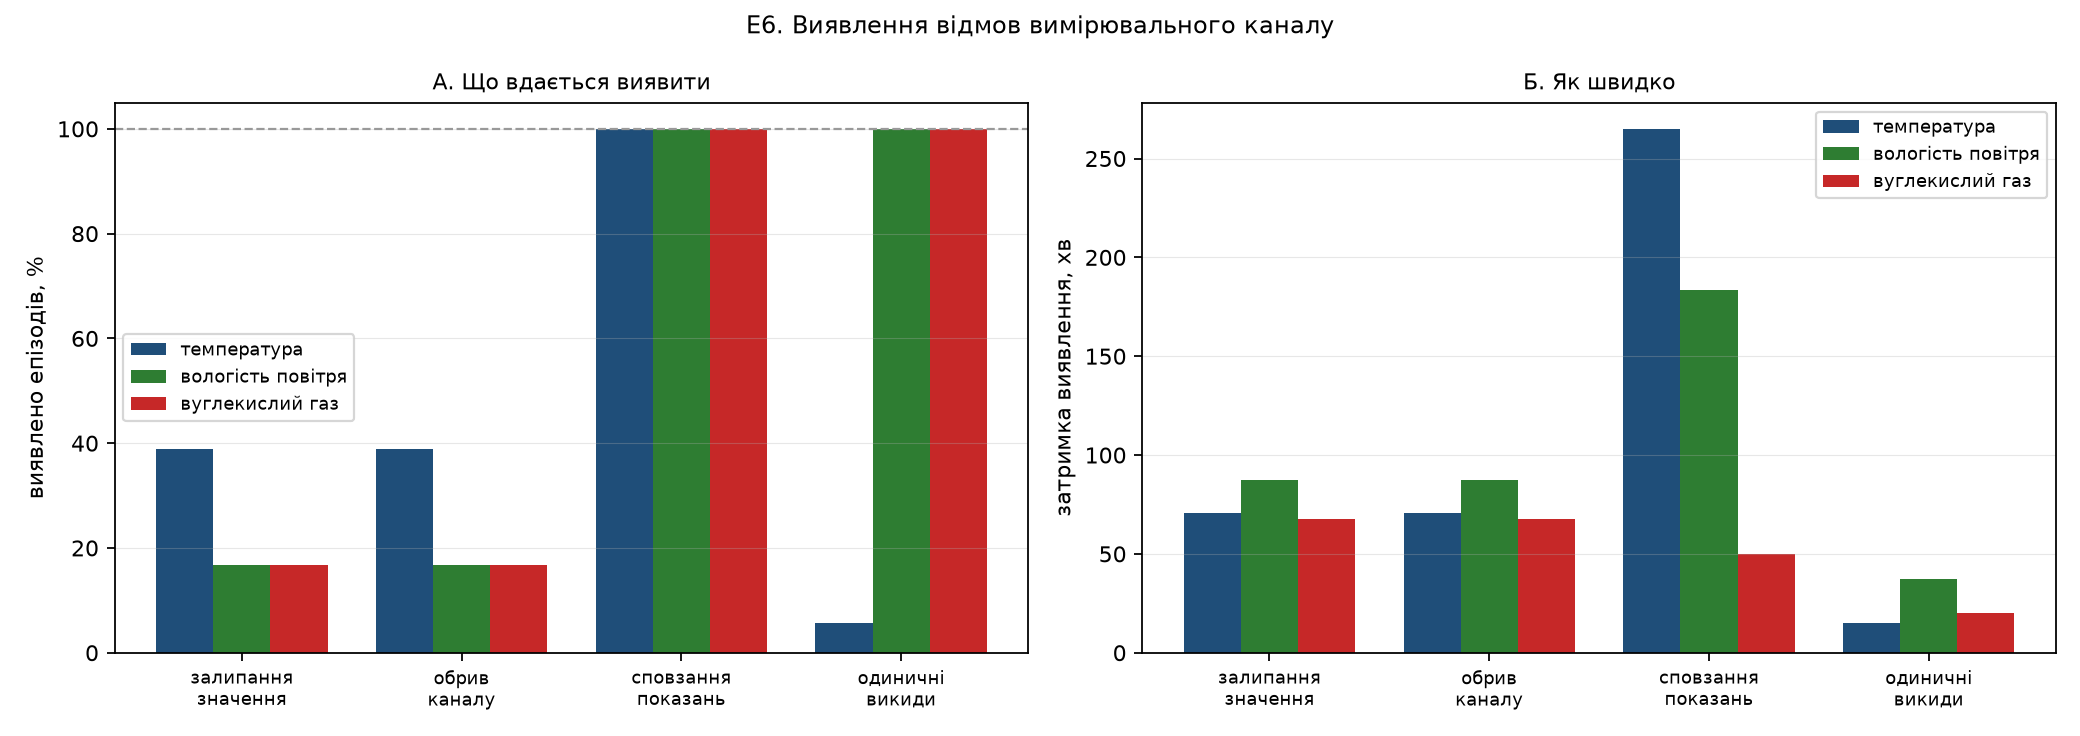

In [23]:
show_figure("fig10_fault_detection.png")

**Найнебезпечніший вид відмови виявляється надійно.** Сповзання показань виявляється у 100 % випадків по всіх каналах. Це головний позитивний результат досліду: саме сповзання становить найбільшу загрозу, оскільки показання лишаються правдоподібними і зовнішніх ознак несправності немає. Заслуга належить накопичувальній сумі — за миттєвим значенням нев'язки така відмова невідрізнима від норми.

Платою є затримка: від 50 хвилин для каналу CO₂ до 265 хвилин для каналу температури. Накопичувачу потрібен час, щоб відрізнити систематичне відхилення від випадкового розкиду. Для повільних процесів теплиці така затримка прийнятна, для швидких контурів керування — ні.

**Залипання значення виявляється погано** — у середньому 24 % епізодів за затримки близько 75 хвилин. Причина в тому, що завмерле показання лишається правдоподібним, а власна похибка оцінки за іншими каналами співмірна з величиною відхилення.

**Обрив каналу дає точно ті самі показники, що й залипання, і це не збіг чисел, а властивість постановки задачі.** При невдалому читанні драйвер повертає останній вдалий результат — так влаштована більшість бібліотек для DHT22 і датчиків з інтерфейсом I²C. Після такої підстановки обрив і залипання являють собою буквально один і той самий сигнал, і розрізнити їх принципово неможливо.

Звідси випливає практична рекомендація до програмного забезпечення приладу: **драйвер зобов'язаний позначати відсутні відліки явно**, а не підставляти попереднє значення. Тоді обрив виявляється миттєво і достовірно, без залучення аналітичної надмірності. Зручна для споживача неперервна видача даних приховує відмову і перетворює тривіально розв'язувану задачу на важку.

**Одиничні викиди** упевнено виявляються в каналах вологості та CO₂ (100 %), але майже не виявляються в каналі температури (5,6 %). Причина у співвідношенні величин: задана амплітуда викиду 2 °C співмірна з власною похибкою оцінки температури за іншими каналами.

---
## 5.8. Дослід E7: реалізовність моделей на мікроконтролері ESP32

Перевіряється, чи можна виконувати прогнозування безпосередньо в приладі, а не передавати дані на сервер. Обчислення на місці вимірювання знімають залежність від каналу зв'язку і зберігають працездатність системи при відмові мережі.

**Що виміряно, а що оцінено розрахунком.** За фактично навченими моделями виміряно кількість параметрів і вузлів, обсяг пам'яті у форматах float32 та int8, кількість елементарних операцій на один прогноз і час обчислення на настільному процесорі. Час виконання на ESP32 отримано розрахунком: кількість операцій ділиться на продуктивність процесора за тактової частоти 240 МГц, з консервативними припущеннями (три такти на множення з накопиченням, п'ять тактів на прохід вузла дерева).

**Натурних вимірювань на платі тут немає.** Розрахункова оцінка призначена для відбраковування завідомо непридатних варіантів, а не для точного передбачення: розбіжність із дійсністю у два-три рази звичайна і залежить від компілятора, влучань у кеш і розміщення моделі у флеш-пам'яті або в оперативній пам'яті.

In [24]:
e7 = show_table("table09_esp32_footprint.csv")
e7[["модель", "RMSE", "параметрів/вузлів", "пам'ять float32, КБ",
    "пам'ять int8, КБ", "час на ESP32, мс", "в ОЗП (int8)", "у флеш-пам'ять"]]

,модель,RMSE,параметрів/вузлів,"пам'ять float32, КБ","пам'ять int8, КБ","час на ESP32, мс",в ОЗП (int8),у флеш-пам'ять
0,Наївний прогноз,1.1576,1,0.004,0.001,0.00,так,так
1,Ridge,0.8715,63,0.200,0.100,0.00,так,так
2,ВипадковийЛіс,0.5834,262442,4100.700,2050.300,0.04,ні,ні
3,ГрадієнтнийБустинг,0.6436,21682,338.800,169.400,0.05,ні,так
4,GRU,0.7878,26689,104.300,26.100,7.28,так,так


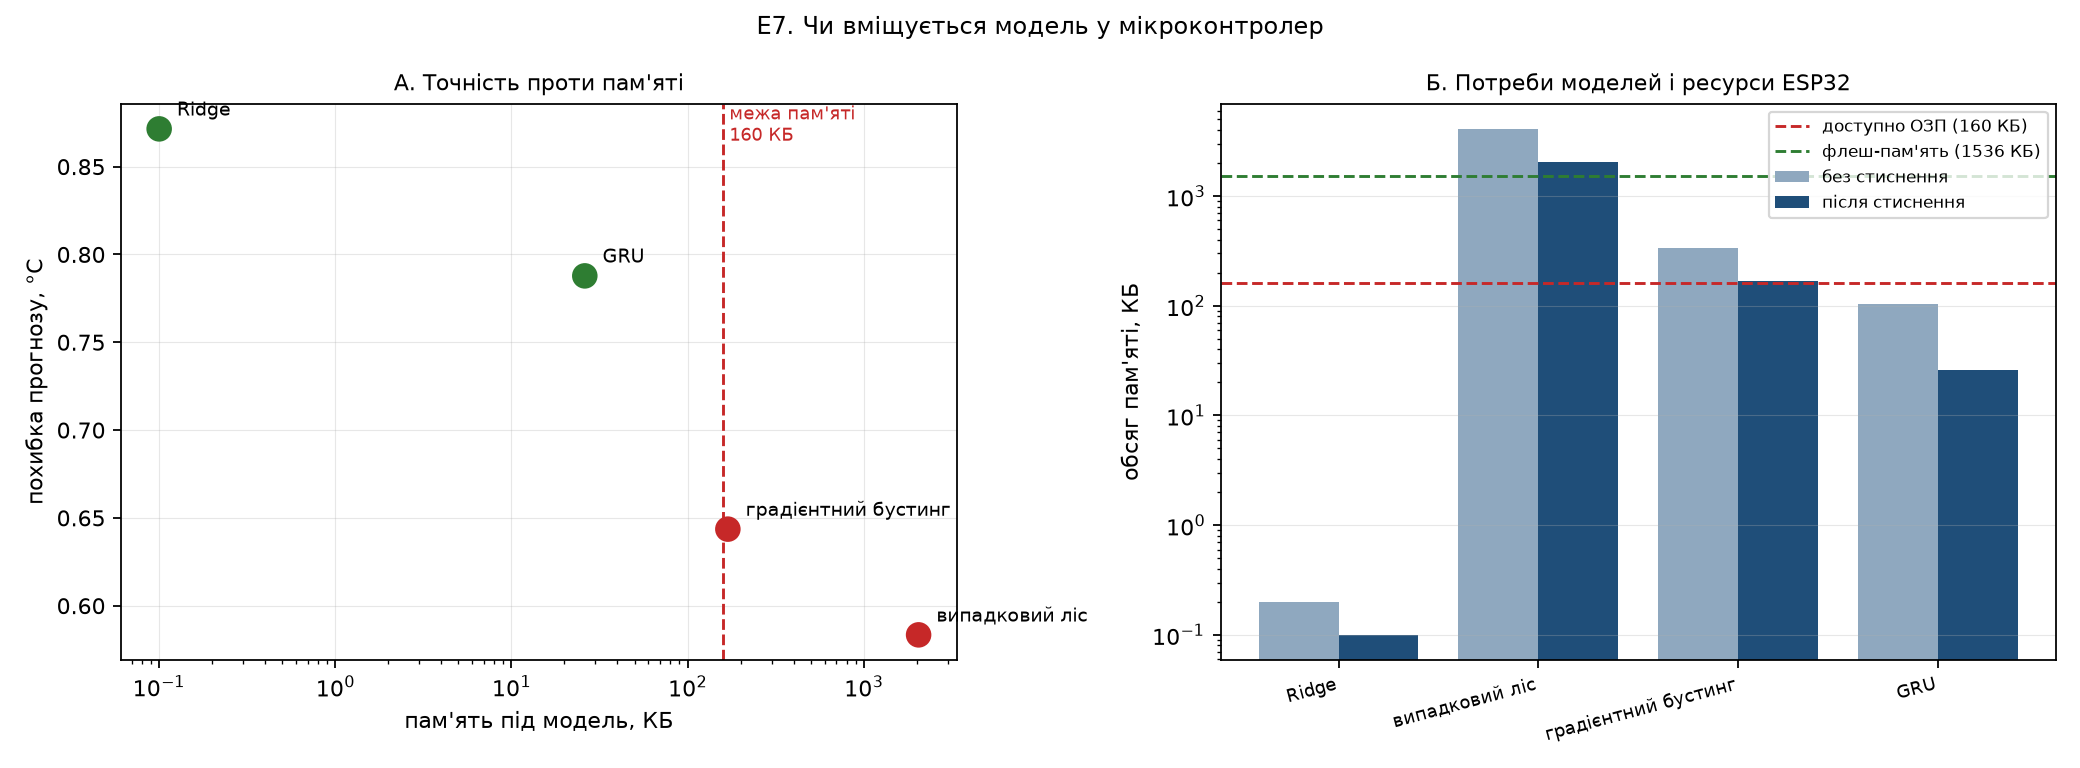

In [25]:
show_figure("fig11_esp32_footprint.png")

**Вибір моделі для вбудованого виконання не збігається з вибором за точністю.** Випадковий ліс, що показав найкращу точність у досліді E1, потребує 4,1 МБ пам'яті у форматі float32 і 2,0 МБ при квантуванні до int8. Він не вміщується ні в оперативну пам'ять мікроконтролера, ні в розділ флеш-пам'яті під застосунок — перевищення становить понад порядок величини. Причина в будові моделі: 150 дерев глибиною до 14 рівнів містять сумарно 262 тисячі вузлів.

Градієнтний бустинг помірніший — 339 КБ і 169 КБ відповідно, — але в доступні 160 КБ оперативної пам'яті все одно не вкладається. Його можна розмістити у флеш-пам'яті ціною сповільнення доступу.

**Рекурентна нейромережа, що програла за точністю, виявляється єдиним придатним варіантом серед складних моделей.** За 26,7 тисячі параметрів вона займає 104 КБ у форматі float32 і 26 КБ після квантування, вільно вміщуючись в оперативну пам'ять. Розрахунковий час одного прогнозу становить 7,3 мс.

Це суттєвий результат для проєктування вимірювальної системи: компактність нейромережевої моделі визначається кількістю параметрів, тоді як ансамбль дерев змушений зберігати всю структуру вирішальних правил. Програш нейромережі в точності на 35 % оплачується виграшем у пам'яті у 78 разів.

**Швидкодія обмеженням не є.** Усі розглянуті моделі вкладаються не лише у п'ятихвилинний період опитування датчиків, але й у секундний цикл швидкого контуру керування з багаторазовим запасом. Єдиним обмежувальним ресурсом виступає обсяг пам'яті.

**Практичний висновок.** Можливі дві схеми побудови системи. Прогнозування безпосередньо в приладі на нейромережевій моделі дає незалежність від каналу зв'язку за точності приблизно на третину гіршої. Передавання даних на сервер із розрахунком ансамблем дерев дає найкращу точність ціною залежності від зв'язку.

---

# 6. Загальні висновки

**За придатністю вимірювальних каналів**

1. **Канали температури і вологості повітря на DHT22 придатні** для прогнозування мікроклімату: відношення сигнал/похибка становить 39 і 16 відповідно, похибка прогнозування за паспортних характеристик датчиків зростає всього в 1,13 і 1,45 раза. Слід ураховувати, що теплиця понад 60 % часу працює за відносної вологості вище 85 %, де нормована похибка датчика зростає.

2. **Канал освітленості на BH1750 придатний за умови калібрування.** Похибка переважно систематична і викликана спектральною невідповідністю: датчик міряє освітленість, зважену за кривою чутливості ока, тоді як для рослини значущий потік фотонів ФАР. Калібрування підвищує відношення сигнал/похибка з 1,5 до 20, але потребує роздільних коефіцієнтів для сонячного світла і світлодіодного досвічування, яке працює 75 % часу.

3. **Канал концентрації CO₂ на SGP30 непридатний,** причому висновок стійкий до прийнятих припущень. Похибка прогнозування зростає в 5,09 раза, відношення сигнал/похибка 0,90. Ба більше, виключення цього каналу з набору ознак **покращує** прогнозування концентрації CO₂ на 15,6 %: канал гірший за своє відсутнє. Рекомендується заміна на датчик NDIR — SCD30 або MH-Z19B.

**За архітектурою вимірювальної системи**

4. **Деградація точності вкрай нерівномірна по каналах.** Обмежувальним є один вимірювальний канал, а не набір бюджетних датчиків загалом. Кошти слід вкладати адресно: заміна одного датчика CO₂ дає більший ефект, ніж модернізація всіх інших каналів.

5. **Відомості про стан виконавчих механізмів цінніші за додаткові датчики.** При послідовному нарощуванні набору ознак прогноз температури спочатку погіршується на 7,4 % і виходить у плюс лише після додавання даних про опалення, кватирки, завіси і досвічування.

6. **Канал вологості субстрату не бере участі в прогнозуванні повітряних параметрів.** Для керування поливом він необхідний, але в розглянутій задачі внеску не дає.

**За способами підвищення точності**

7. **Фільтрація не відновлює точність і здатна її погіршити** (для каналу температури — на 70 % від величини втрат): похибки бюджетних датчиків переважно систематичні, а фільтр бореться з випадковою складовою і вносить запізнення.

8. **Калібрування за образцовим приладом — основний засіб**, що повертає від 76 до 100 % втраченої точності. Однак для каналу CO₂ воно недостатнє: відкалібрований SGP30 дає 61 ppm проти 35 ppm у некаліброваного SCD30.

9. **Поділ похибки за способом усунення має практичну цінність.** Для каналу вологості переважає систематичне зміщення (46 %), що усувається калібруванням. Для каналу CO₂ переважають складові, формально усувні повіркою, але фактично неусувні в умовах експлуатації.

**За надійністю і прогнозуванням**

10. **Відмови типу «сповзання показань» виявляються у 100 % випадків** методом аналітичної надмірності з накопичувальною сумою, за частоти хибних тривог близько одного спрацювання на добу. Затримка виявлення становить від 50 до 265 хвилин. Залипання значення виявляється погано (24 %), а обрив каналу невідрізнимий від залипання, якщо драйвер підставляє останнє вдале показання.

11. **Ансамблі вирішальних дерев переважають рекурентну нейромережу** за даного обсягу вибірки. Виграш над наївним прогнозом зростає з горизонтом і сягає 62 % на годинному горизонті.

12. **Для вбудованого виконання придатна не найточніша модель.** Випадковий ліс потребує 2,0 МБ пам'яті навіть після квантування і не вміщується в ESP32. Рекурентна нейромережа займає 26 КБ і вільно розміщується в оперативній пам'яті, програючи за точністю близько третини.

## Обмеження роботи

Результати отримані методом модельного експерименту і потребують підтвердження натурними випробуваннями зібраного приладу.

Частина параметрів моделей похибок (інерційність датчиків у корпусі, частка збоїв обміну, дрейф нульової лінії) прийнята як експертна оцінка, оскільки виробником не нормується; для каналу вологості субстрату експертними є всі параметри. Коефіцієнти методичної похибки перевірені аналізом чутливості (розділ 5.4).

Опорний ряд отримано з даних промислової теплиці з мінеральною ватою як субстратом, що слід ураховувати при перенесенні висновків на ґрунтові теплиці. Перерахунок фотосинтетично активної радіації в освітленість виконано з коефіцієнтом, справедливим для сонячного спектра.

Внесок систематичного зміщення для каналу температури визначити не вдалося: розкид між примірниками датчиків перекриває сам ефект. Показники виявлення відмов залежать від прийнятих амплітуд відмов, які задані експертно.

Оцінки швидкодії на мікроконтролері (розділ 5.8) отримані розрахунком за кількістю операцій і не підтверджені вимірюваннями на платі.

## Подальша робота

Натурні випробування зібраного приладу з образцовими засобами вимірювань; підтвердження розрахункових оцінок швидкодії та обсягу пам'яті на платі ESP32; перевірка висновків на теплицях із ґрунтовим вирощуванням.